In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import lissa as li

from sktime.transformations.series.vmd import VmdTransformer
from scipy.signal import hilbert

In [2]:
baseData = li.DataPreparer("../data","full_sensor_1h [old].csv")
entireData,pumpList = li.FailureMerge(baseData,"../data","respostas.csv")
entireData = li.FeatureCreation(entireData)

número de bombas: 38
número de runs: 57


In [3]:
Headers = [
    "ESP Vibration X",
    "ESP Vibration Y"
    #'ESP discharge temperature sensor',
    # 'ESP intake temperature',
    # 'ESP motor temperature',
    # 'Well head Temperature',
    # 'ESP intake Pressure',
    # 'ESP discharge pressure',
    # #'ESP differential pressure',
    # 'Well head pressure',
    # 'VSD power frequency',
    # 'ESP Motor Voltage',
    # 'Current Mean', 
    # #'ESP Vibration Module',
    # #'ESP Power'
    ]

<Axes: xlabel='time'>

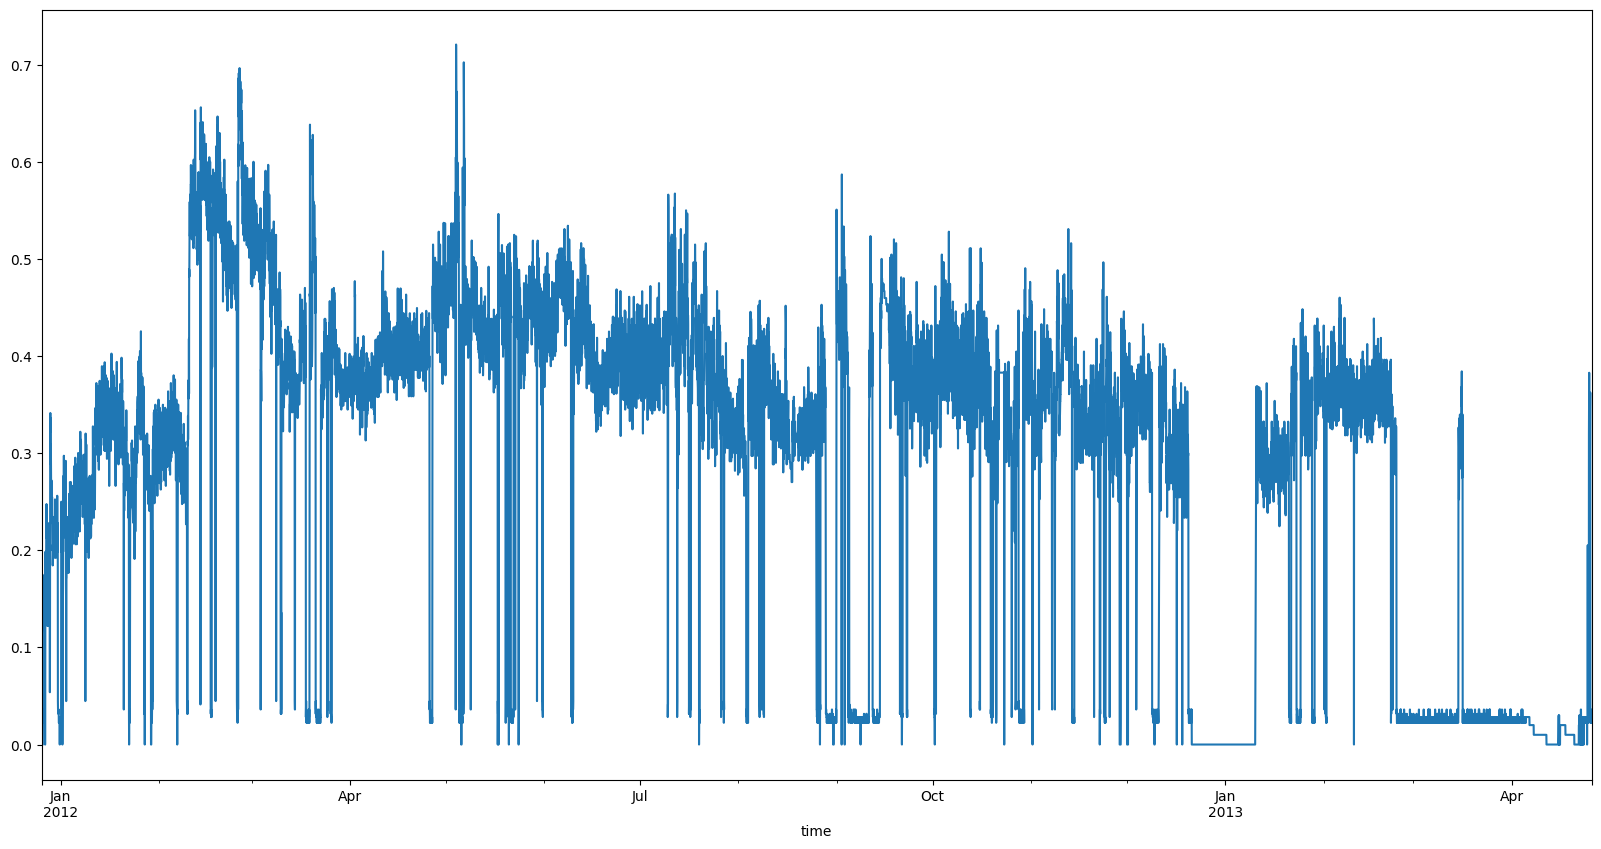

In [4]:
pumpData = entireData.groupby("Well Run").get_group("B-18 2")[Headers].pow(2).sum(axis=1).pow(1/2)

pumpData.plot(figsize=(20,10))

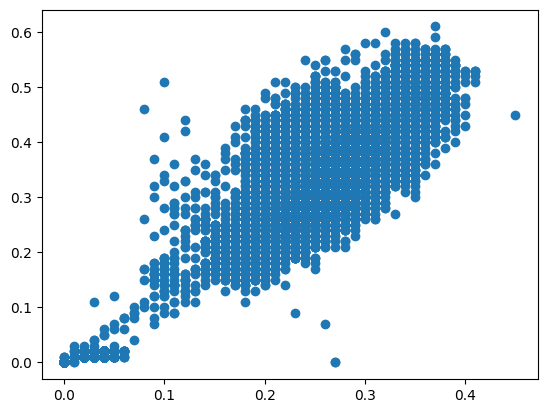

In [13]:
pumpData = entireData.groupby("Well Run").get_group("B-10 1")[Headers]
plt.scatter(pumpData["ESP Vibration X"],pumpData["ESP Vibration Y"])


In [167]:
vmdModel = VmdTransformer(K=5,returned_decomp="u")
#prop = "ESP discharge pressure"

test = vmdModel.fit_transform(pumpData)
test.index = pumpData.index

In [191]:
angle = np.unwrap(np.angle(hilbert(test)))
instantAngle = pd.DataFrame(angle,index=pumpData.index).diff()



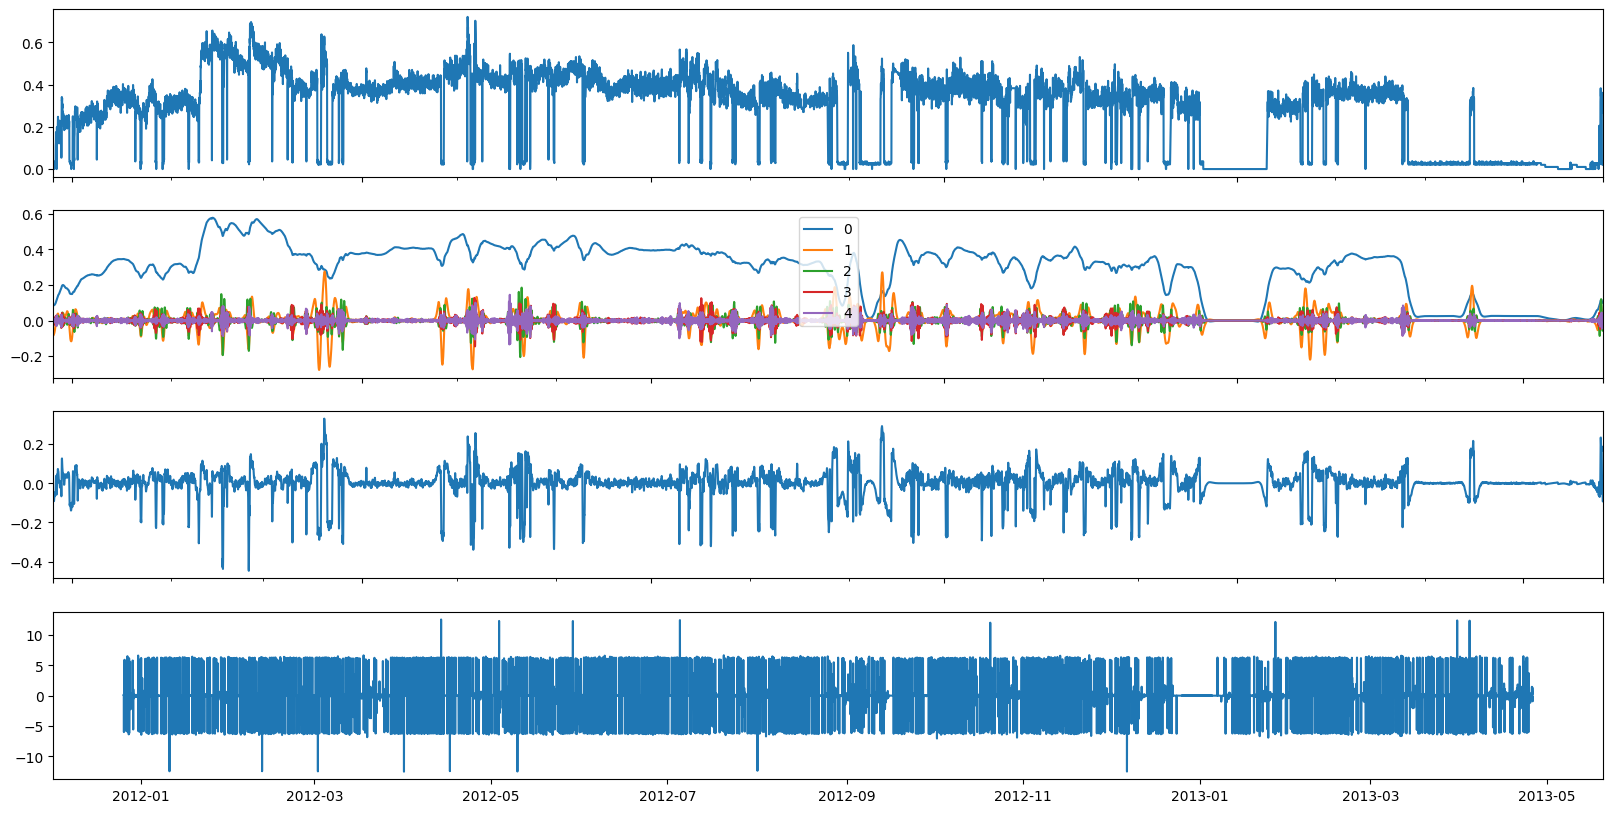

In [202]:
fig,axs = plt.subplots(4,1)

test.plot(ax=axs[1],figsize=(20,10))

pumpData.plot(ax=axs[0],sharex=True)

(test[[1,2,3,4]].sum(axis=1)).plot(ax=axs[2])

axs[3].plot(instantAngle[3])

<Axes: >

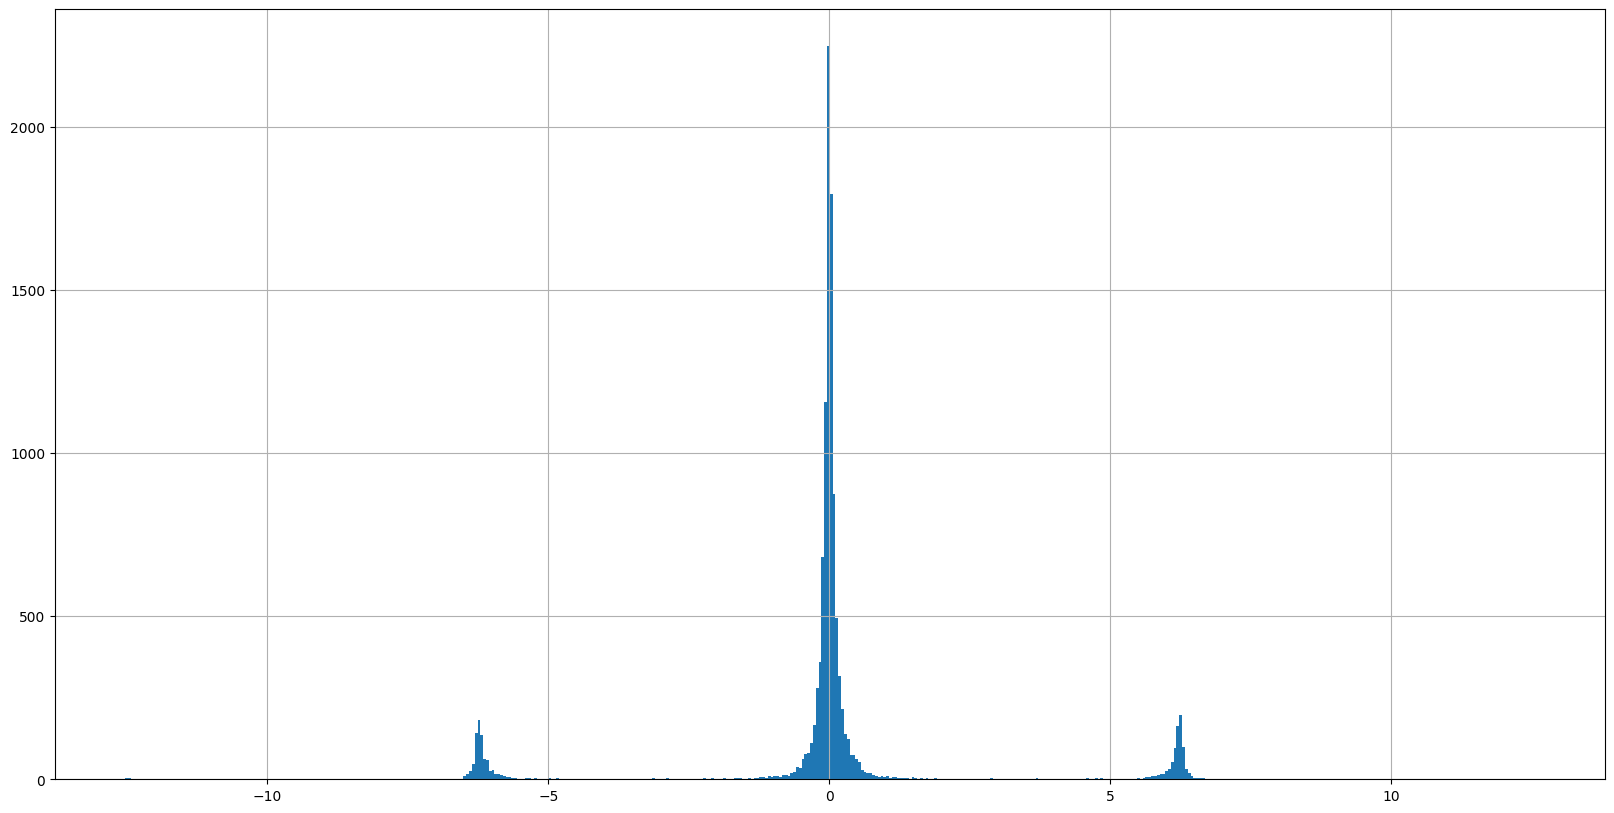

In [201]:
instantAngle[3].hist(bins=500,figsize=(20,10))

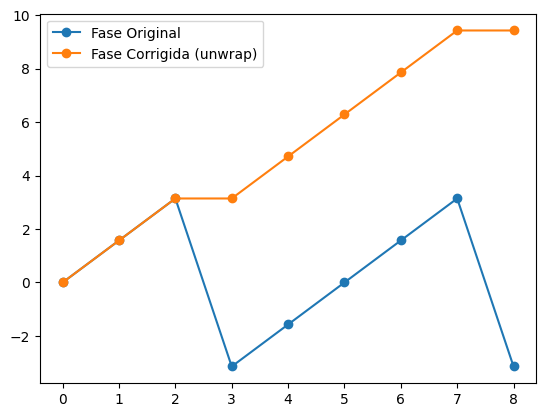

In [194]:
import numpy as np
import matplotlib.pyplot as plt

# Criando um vetor de fases com saltos de 2π
phase = np.array([0, np.pi/2, np.pi, -np.pi, -np.pi/2, 0, np.pi/2, np.pi, -np.pi])

# Aplicando np.unwrap
unwrapped_phase = np.unwrap(phase)

# Plotando
plt.plot(phase, 'o-', label="Fase Original")
plt.plot(unwrapped_phase, 'o-', label="Fase Corrigida (unwrap)")
plt.legend()
plt.show()
